# Fully-Online (Prequential) Just-In-Time Evaluation

This is the project's *true* protocol. Commits arrive one by one in chronological
order, and for **every** commit we, in order:

1. **Predict** its label using only the KG/history known so far;
2. **Evaluate** — reveal the true label and update running (cumulative + rolling)
   metrics;
3. **Grow** the KG state — the commit's relational/graph evidence is added
   (developer/file/global bug-rate counters advance; the graph used by
   PPR/embeddings includes it);
4. **Learn** — every model is updated with the now-known (features, label).

We run **within-project baselines** and **KG-native inference methods** in the
*same* stream, so they are compared under one identical online protocol.
(Engine: `inference/online_jit.py`. The earlier offline/blocked evaluations are
kept separately.)

In [1]:
import sys, os, pickle
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT/'inference').exists() and ROOT != ROOT.parent: ROOT = ROOT.parent
os.chdir(ROOT)
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi']=110

R = pickle.load(open('outputs/online_jit_results.pkl','rb'))
meta = R['meta']
print(f"streamed commits={meta['N']-meta['warmup']} (warmup {meta['warmup']}), "
      f"stream bug-rate={meta['stream_bug']:.3f}")

streamed commits=5642 (warmup 2417), stream bug-rate=0.241


## 1. Final prequential comparison (cumulative over the whole stream)

**`F1_online` is the headline operating-point metric** — the buggy-class F1 with
the decision threshold tuned *online* on past data only (re-tuned every 150
commits). It answers the practical JIT question (do we actually catch bugs at a
usable precision?), where plain F1@0.5 is unfair to uncalibrated scores. We sort
by it; PR-AUC / ROC-AUC are reported as threshold-free ranking metrics.

In [2]:
rows=[]
for m,d in R['methods'].items():
    rows.append(dict(method=d['name'], group=d['group'], **d['cum']))
df=pd.DataFrame(rows).set_index('method')
df=df[['group','F1_online','F1','PR_AUC','ROC_AUC','MCC','Brier']].sort_values('F1_online',ascending=False)
df.round(3)

,group,F1_online,F1,PR_AUC,ROC_AUC,MCC,Brier
method,,,,,,,
Fusion (metrics+priors+TFIDF+PPR),kg,0.593,0.552,0.598,0.822,0.395,0.225
Personalized PageRank,kg,0.511,0.512,0.383,0.727,0.322,0.220
Structural TF-IDF (incremental),kg,0.490,0.486,0.420,0.719,0.284,0.333
GradBoost / JIT metrics,baseline,0.481,0.445,0.469,0.711,0.296,0.179
KG embedding (SVD/LSA),kg,0.479,0.460,0.427,0.690,0.288,0.220
RandomForest / JIT metrics,baseline,0.478,0.240,0.478,0.723,0.237,0.162
Relational priors (wvRN),kg,0.477,0.048,0.428,0.703,0.097,0.166
LR / JIT metrics (incremental),baseline,0.464,0.467,0.348,0.671,0.246,0.427
Naive prior bug-rate,baseline,0.391,0.000,0.223,0.468,0.000,0.188


## 2. The headline metrics — online buggy-F1 and PR-AUC
Baselines (orange) vs KG-native methods (blue). **Left = `F1_online`** (the
deployment metric); right = PR-AUC. Dashed line = random.

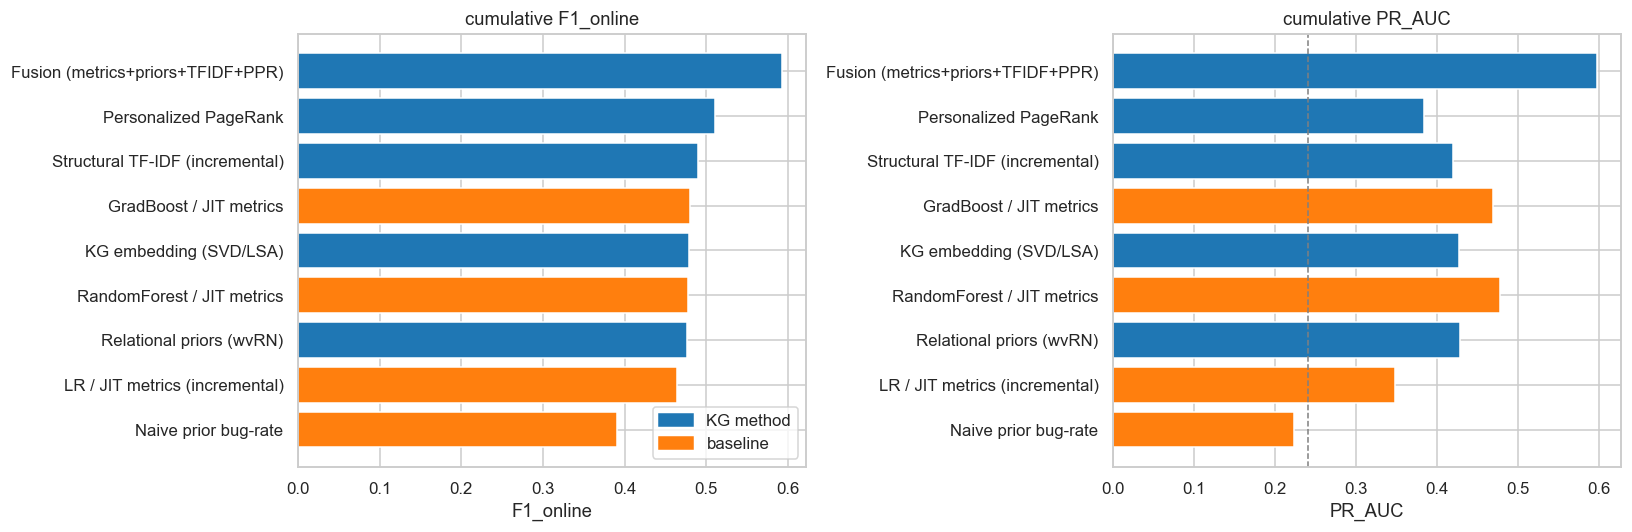

In [3]:
order=df.sort_values('F1_online',ascending=False).index.tolist()
gof={d['name']:d['group'] for d in R['methods'].values()}
colors=['#1f77b4' if gof[m]=='kg' else '#ff7f0e' for m in order]
fig,ax=plt.subplots(1,2,figsize=(15,5))
for a,metric,rnd in [(ax[0],'F1_online',None),(ax[1],'PR_AUC',meta['stream_bug'])]:
    a.barh(range(len(order)),[df.loc[m,metric] for m in order],color=colors)
    a.set_yticks(range(len(order))); a.set_yticklabels(order); a.invert_yaxis()
    if rnd is not None: a.axvline(rnd,ls='--',c='gray',lw=1)
    a.set_title(f'cumulative {metric}'); a.set_xlabel(metric)
from matplotlib.patches import Patch
ax[0].legend(handles=[Patch(color='#1f77b4',label='KG method'),Patch(color='#ff7f0e',label='baseline')],loc='lower right')
plt.tight_layout(); plt.show()

## 3. Online evaluation *as commits arrive* — rolling-window metric trajectories
This is the heart of the JIT protocol: the metric is recomputed over a moving
window as the stream advances, so we see performance evolve (and drift) over the
project's history.

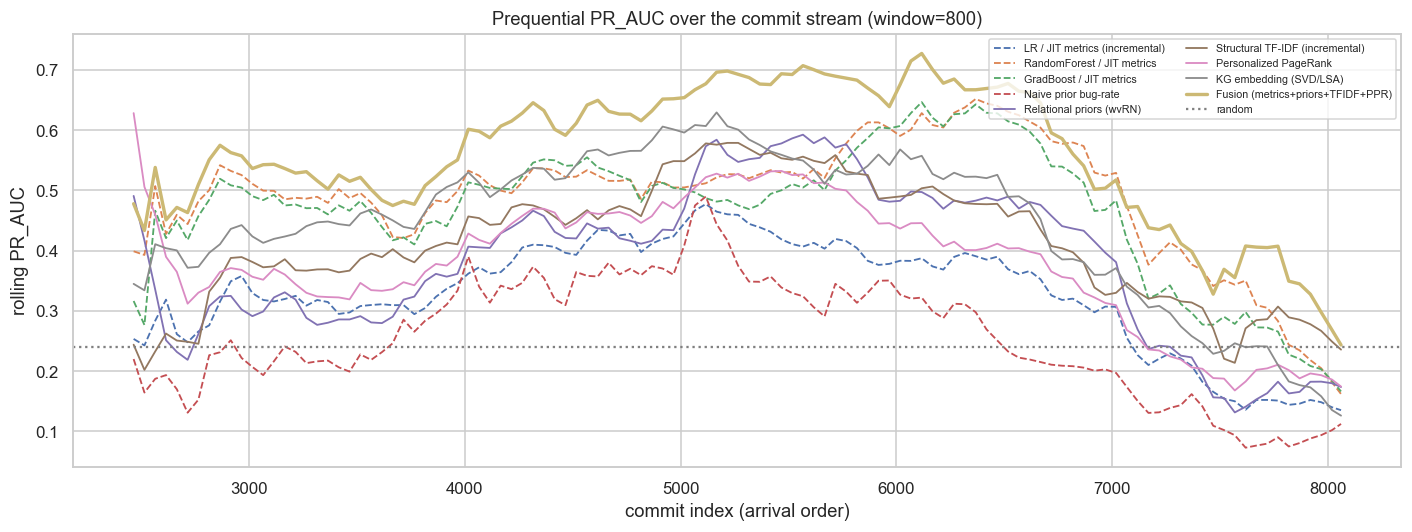

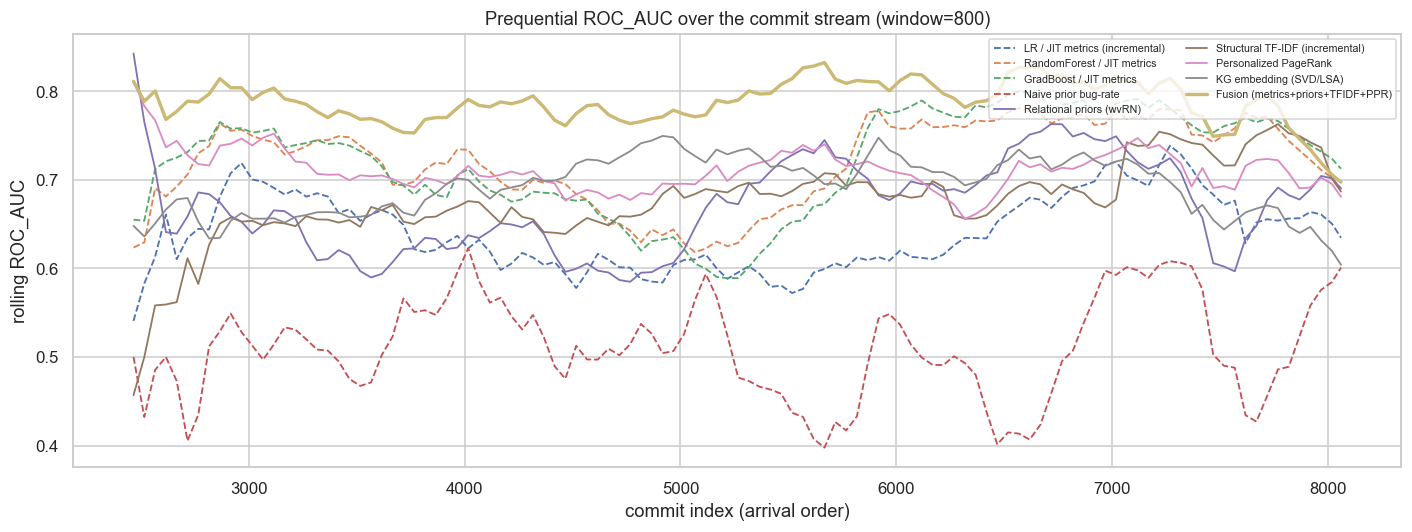

In [4]:
def plot_traj(metric):
    fig,ax=plt.subplots(figsize=(13,5))
    for m,d in R['methods'].items():
        t=R['traj'][m]; style='-' if d['group']=='kg' else '--'
        lw=2.2 if m=='K_fusion' else 1.2
        ax.plot(t['idx'], t[metric], style, lw=lw, label=d['name'])
    if metric=='PR_AUC': ax.axhline(meta['stream_bug'],ls=':',c='gray',label='random')
    ax.set_xlabel('commit index (arrival order)'); ax.set_ylabel(f'rolling {metric}')
    ax.set_title(f'Prequential {metric} over the commit stream (window=800)')
    ax.legend(fontsize=7,ncol=2,loc='upper right'); plt.tight_layout(); plt.show()
plot_traj('PR_AUC'); plot_traj('ROC_AUC')

## 4. Fusion vs the best baseline, over time
Solid = KG Fusion; dashed = the strongest JIT-metrics baseline. Shows whether the
KG advantage holds *throughout* the stream or only in places.

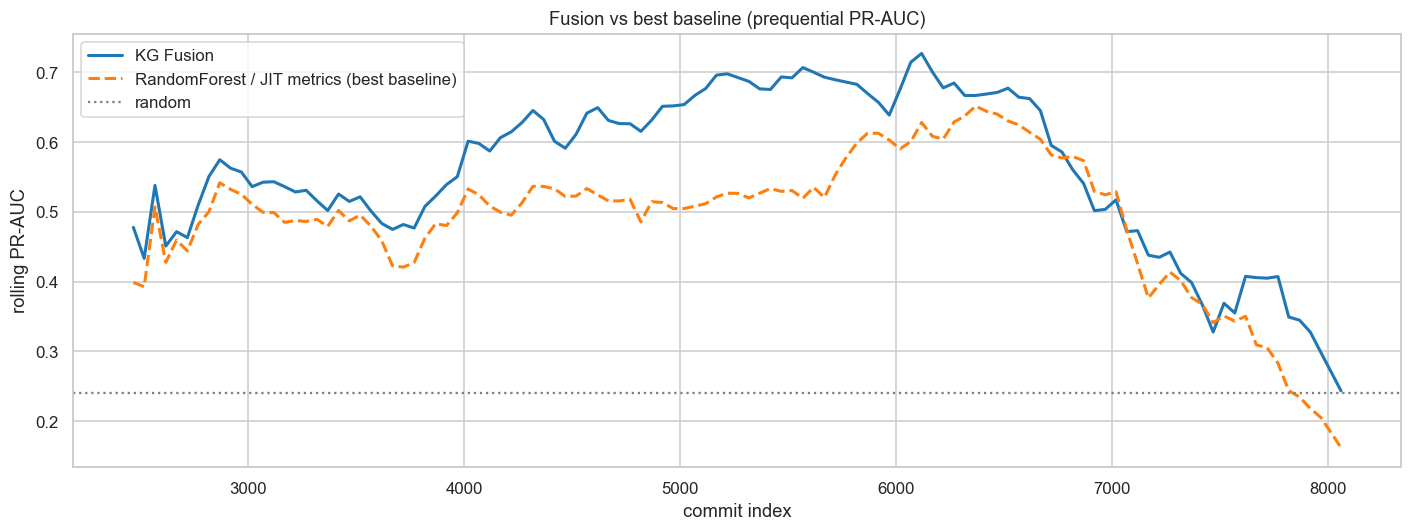

Final cumulative PR-AUC:  Fusion=0.598   best baseline (RandomForest / JIT metrics)=0.478


In [5]:
base_methods=[k for k,v in R['methods'].items() if v['group']=='baseline' and k!='B_naive_rate']
best_base=max(base_methods,key=lambda k:R['methods'][k]['cum']['PR_AUC'])
fig,ax=plt.subplots(figsize=(13,5))
for k,lab,st,c in [('K_fusion','KG Fusion','-','#1f77b4'),(best_base,R['methods'][best_base]['name']+' (best baseline)','--','#ff7f0e')]:
    ax.plot(R['traj'][k]['idx'],R['traj'][k]['PR_AUC'],st,lw=2,color=c,label=lab)
ax.axhline(meta['stream_bug'],ls=':',c='gray',label='random')
ax.set(xlabel='commit index',ylabel='rolling PR-AUC',title='Fusion vs best baseline (prequential PR-AUC)')
ax.legend(); plt.tight_layout(); plt.show()
print('Final cumulative PR-AUC:  Fusion=%.3f   best baseline (%s)=%.3f'
      % (R['methods']['K_fusion']['cum']['PR_AUC'], R['methods'][best_base]['name'], R['methods'][best_base]['cum']['PR_AUC']))

## 5. Fusion feature ablation (online)

The **Fusion** combines four feature streams:
**M** = JIT metrics, **T** = structural TF-IDF, **R** = relational priors,
**P** = PPR score. To measure each one's importance we evaluate **all 15
non-empty subsets** (1, 2, 3, or 4 features) under the *same* fully-online
prequential protocol — a balanced logistic regression retrained on the expanding
past window over the selected features.

The four feature streams are precomputed once (the priors-growth and per-block
PPR are identical regardless of the subset), so the 15 runs are cheap.

In [6]:
import sys; sys.path.insert(0, str(ROOT/'inference'))
import online_jit as oj
S = oj.precompute_streams()          # cached -> outputs/online_jit_streams.pkl
ABL = oj.ablation_all(S)             # all 15 subsets, online prequential
adf = pd.DataFrame([
    dict(combo=k, n_features=v['n'], **{m: v['cum'][m] for m in ['F1_online','F1','PR_AUC','ROC_AUC','MCC']})
    for k,v in ABL.items()
]).set_index('combo').sort_values('F1_online', ascending=False)
print('M=JIT metrics  T=structural TF-IDF  R=relational priors  P=PPR score')
print('(F1_online = buggy-F1 with online-tuned threshold = the operating-point metric)')
adf.round(3)

M=JIT metrics  T=structural TF-IDF  R=relational priors  P=PPR score
(F1_online = buggy-F1 with online-tuned threshold = the operating-point metric)


,n_features,F1_online,F1,PR_AUC,ROC_AUC,MCC
combo,,,,,,
M+T+R,3,0.604,0.561,0.608,0.828,0.410
M+T+R+P,4,0.601,0.563,0.606,0.828,0.411
T+R+P,3,0.590,0.554,0.600,0.821,0.397
T+R,2,0.587,0.551,0.600,0.821,0.394
M+R+P,3,0.563,0.537,0.560,0.807,0.372
M+R,2,0.558,0.534,0.561,0.806,0.368
M+T+P,3,0.546,0.529,0.546,0.792,0.359
R+P,2,0.526,0.514,0.523,0.776,0.331
R,1,0.523,0.506,0.524,0.774,0.318


### 5a. All 15 combinations ranked — online buggy-F1 and PR-AUC
Bars coloured by how many features the combination uses. **Left = `F1_online`**
(operating point); right = PR-AUC (ranking).

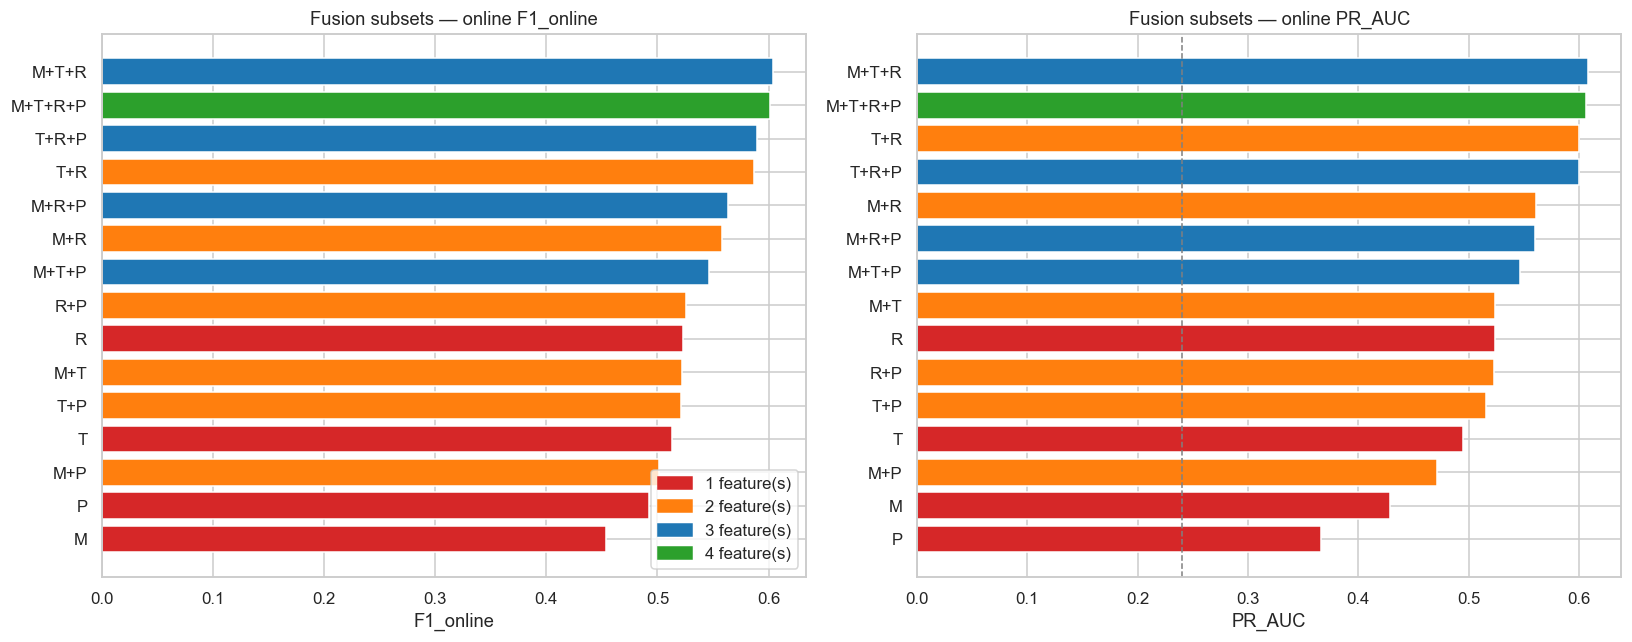

In [7]:
cmap = {1:'#d62728', 2:'#ff7f0e', 3:'#1f77b4', 4:'#2ca02c'}
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for a, metric in [(ax[0],'F1_online'), (ax[1],'PR_AUC')]:
    order = adf.sort_values(metric, ascending=True).index.tolist()
    colors = [cmap[adf.loc[c,'n_features']] for c in order]
    a.barh(range(len(order)), [adf.loc[c,metric] for c in order], color=colors)
    a.set_yticks(range(len(order))); a.set_yticklabels(order)
    a.set_xlabel(metric); a.set_title(f'Fusion subsets — online {metric}')
ax[1].axvline(S['y'][S['W']:].mean(), ls='--', c='gray', lw=1)
from matplotlib.patches import Patch
ax[0].legend(handles=[Patch(color=cmap[k], label=f'{k} feature(s)') for k in [1,2,3,4]], loc='lower right')
plt.tight_layout(); plt.show()

### 5b. Single-feature strength and leave-one-out importance (by online F1)
*Left:* each feature alone. *Right:* the drop in `F1_online` when each feature is
removed from the full M+T+R+P fusion (bigger drop = more important / less
redundant; a negative bar means the feature slightly *hurts*).

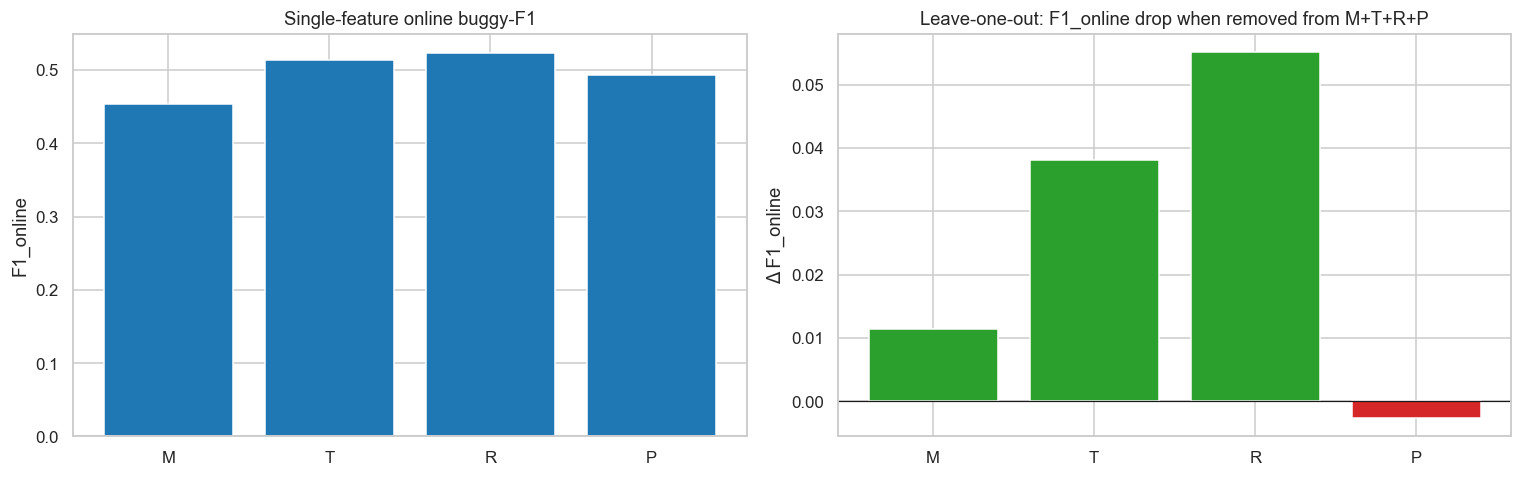

Full M+T+R+P  F1_online = 0.601  PR-AUC = 0.606
Single-feature F1_online: {'M': 0.453, 'T': 0.513, 'R': 0.523, 'P': 0.493}
Leave-one-out drop      : {'M': 0.011, 'T': 0.038, 'R': 0.055, 'P': -0.003}


In [8]:
MET='F1_online'
singles = {oj.FEAT_ABBR[f]: ABL[oj.FEAT_ABBR[f]]['cum'] for f in oj.FEATURES}
full = ABL['M+T+R+P']['cum'][MET]
loo = {}
for f in oj.FEATURES:
    rest = '+'.join(oj.FEAT_ABBR[g] for g in oj.FEATURES if g!=f)
    loo[oj.FEAT_ABBR[f]] = full - ABL[rest]['cum'][MET]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(list(singles), [v[MET] for v in singles.values()], color='#1f77b4')
ax[0].set_title('Single-feature online buggy-F1'); ax[0].set_ylabel('F1_online')
ax[1].bar(list(loo), list(loo.values()), color=['#2ca02c' if v>=0 else '#d62728' for v in loo.values()])
ax[1].axhline(0, c='k', lw=0.8)
ax[1].set_title('Leave-one-out: F1_online drop when removed from M+T+R+P'); ax[1].set_ylabel('Δ F1_online')
plt.tight_layout(); plt.show()
print('Full M+T+R+P  F1_online =', round(full,3), ' PR-AUC =', round(ABL['M+T+R+P']['cum']['PR_AUC'],3))
print('Single-feature F1_online:', {k: round(v[MET],3) for k,v in singles.items()})
print('Leave-one-out drop      :', {k: round(v,3) for k,v in loo.items()})

### 5c. Trajectories — singles vs full fusion over the stream

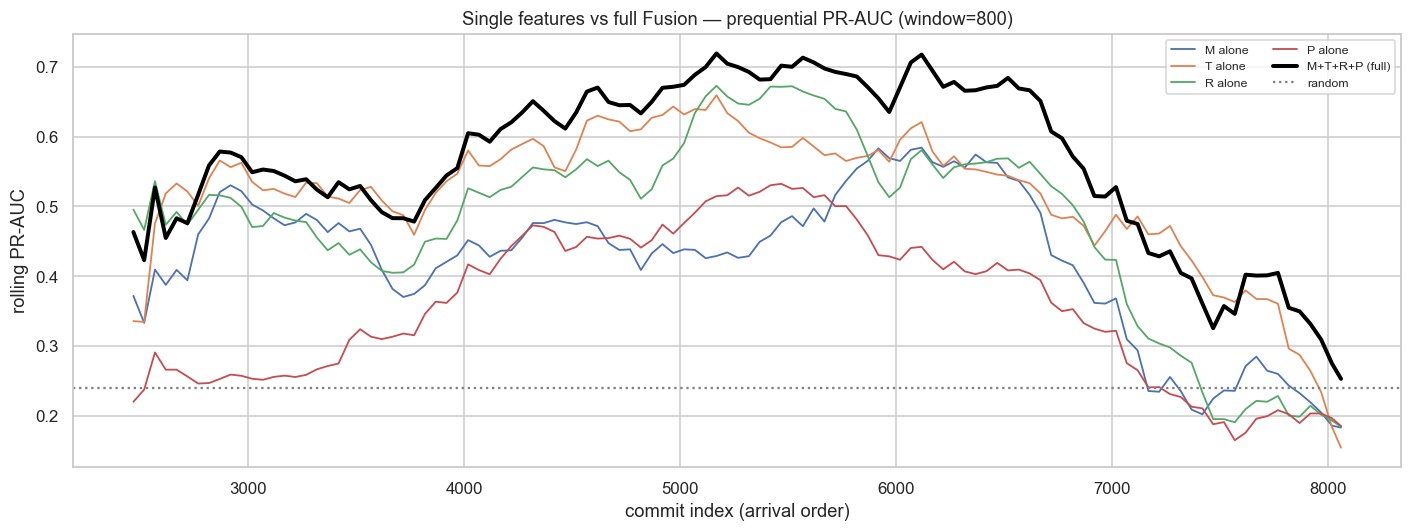

In [9]:
fig, ax = plt.subplots(figsize=(13,5))
for f in oj.FEATURES:
    t = ABL[oj.FEAT_ABBR[f]]['traj']; ax.plot(t['idx'], t['PR_AUC'], lw=1.2, label=oj.FEAT_ABBR[f]+' alone')
t = ABL['M+T+R+P']['traj']; ax.plot(t['idx'], t['PR_AUC'], lw=2.6, color='black', label='M+T+R+P (full)')
ax.axhline(S['y'][S['W']:].mean(), ls=':', c='gray', label='random')
ax.set(xlabel='commit index (arrival order)', ylabel='rolling PR-AUC',
       title='Single features vs full Fusion — prequential PR-AUC (window=800)')
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

### 5d. Reading the ablation
- The **full M+T+R+P** fusion should top the ranking; how far ahead of the best
  3-feature subset it sits tells you how much the last feature still adds.
- **Single-feature** bars rank the standalone strength of each signal.
- **Leave-one-out** is the cleanest importance measure: a large PR-AUC drop when
  a feature is removed means it carries information the others do not; a near-zero
  drop means it is largely redundant given the rest.

## 6. Notes
* This is a **single streaming pass**: each commit is predicted once (before the
  model ever sees it), then used to grow the KG and update every learner — no
  look-ahead leakage anywhere.
* Linear models learn **incrementally** (`partial_fit`); tree/fusion/embedding
  models are **retrained on the expanding past window** periodically; graph
  features (PPR, SVD embedding) are **refreshed over the past-only graph**.
* Compare with the blocked/offline evaluation in `inference_results.ipynb` and
  the controlled same-split baseline comparison in `inference/compare_baselines.py`.